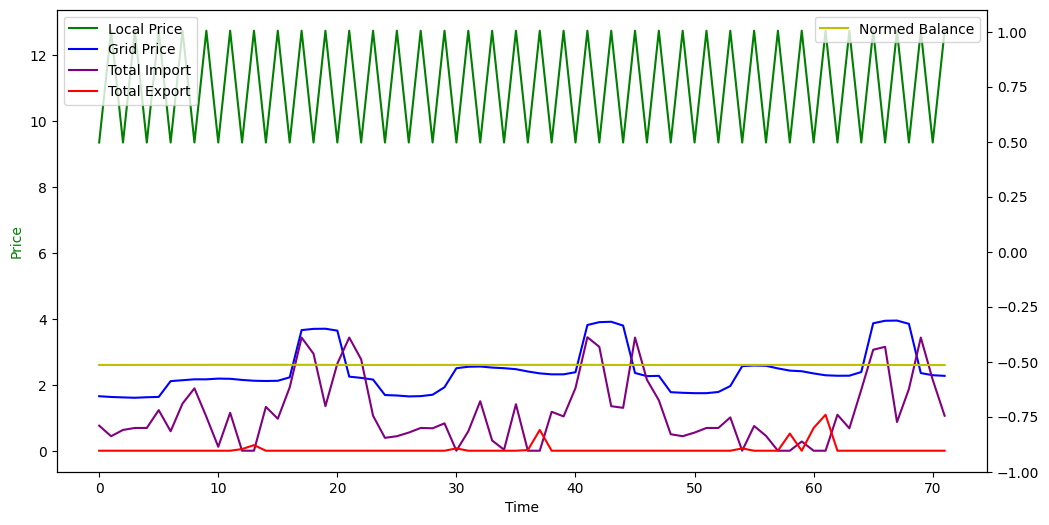

-0.5145070203373563
-0.5150210158890819



In [7]:
import matplotlib.pyplot as plt
import cloudpickle
import numpy as np
from datamanager import DataManager

path = "output/flex_multi_combined/results.pkl"
outputfolder = path
with open(path, "rb") as file:
    results = cloudpickle.load(file)
results = list(results)

for rollout in results:
    aid = "CM"
    prices = []
    norm_balance = []
    grid_price = []
    prosumers_loss = []
    mediator_loss = []
    total_export = []
    total_import = []
    total_import += list(rollout.metrics["cm/total_import"])
    total_export += list(rollout.metrics["cm/total_export"])
    prosumers_loss += list(rollout.metrics["env/total_loss"])
    mediator_loss += list(rollout.metrics["cm/mediator_netloss"])
    grid_price += list(rollout.metrics["cm/current_grid_price"])
    norm_balance += list(rollout.metrics["cm/normed_balance"])
    prices += list(rollout.metrics["env/current_price"])

    start = 48*30*8
    end = start + 48*3

    total_import = total_import[start+1:end+1:2]
    total_export = total_export[start+1:end+1:2]
    prosumers_loss = prosumers_loss[start:end:2]
    mediator_loss = mediator_loss[start:end:2]
    norm_balance = norm_balance[start:end:2]
    grid_price = grid_price[start:end:2]
    prices = prices[start:end:2]

    
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax2 = ax1.twinx()
    ax1.plot(prices, 'g-', label="Local Price")
    ax1.plot(grid_price, 'b-', label="Grid Price")
    ax1.plot(total_import, color="purple", label="Total Import")
    ax1.plot(total_export, color="red", label="Total Export")
    ax2.plot(norm_balance, 'y-', label="Normed Balance")
    #ax2.plot(prosumers_loss, 'r-', label="prosumers loss")
    #ax2.plot(total_export, 'k-', label="Total Export")
    ax2.set_ylim(-1, 1.1)
    #ax1.set_ylim(0, 8)
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Price', color='g')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.show()

    print(np.mean(norm_balance))
    print(norm_balance[len(norm_balance)-1])
    print()

   

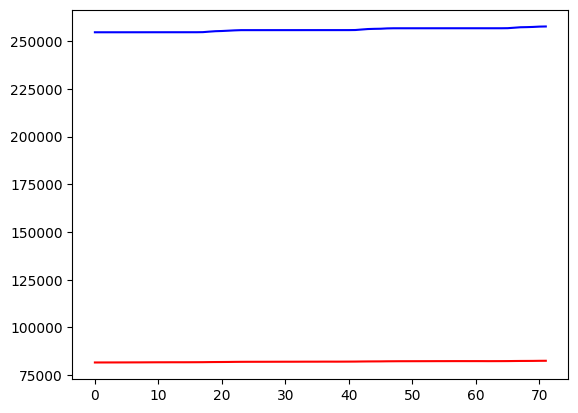

In [9]:
plt.plot(mediator_loss, color='blue')
plt.plot(prosumers_loss, color='red')
# plt.plot(total_export, color='green')
plt.show()